<a href="https://colab.research.google.com/github/nabel14/tugasindividu-deteksi-objek-menggunakan-yolo/blob/main/Convert_Pytorch_Model_(_pt)_to_ONNX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.1 MB/s eta 0:00:00


In [12]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="T4UWZts1V6B6pRZnxncJ")
project = rf.workspace("bs-workspace-dtisr").project("sunflowers-gifls")
version = project.version(2)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to sunflowers-2 in yolo26:: 100%|██████████| 295/295 [00:00<00:00, 10485.14it/s]


In [13]:
from ultralytics import YOLO

# 1. Inisialisasi model dasar YOLOv26 versi Nano
model = YOLO("yolo26n.pt")

# 2. Memulai proses training
hasil = model.train(
    data=f"{dataset.location}/data.yaml",  # Menunjuk otomatis ke folder dataset yang baru saja diunduh dari Roboflow
    epochs=65,                             # Jumlah putaran latihan. 50-100 biasanya cukup untuk permulaan
    imgsz=320,                             # Resolusi disamakan dengan hasil 'Resize' 320x320 di Roboflow kamu
    optimizer="MuSGD"                      # Memaksa model menggunakan optimizer MuSGD YOLOv26 untuk stabilitas
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/sunflowers-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=65, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=MuSGD, overlap_mask=True, patience=100

In [14]:
metrics = model.val()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 668.4±251.8 MB/s, size: 17.1 KB)
val: Scanning /content/sunflowers-2/valid/labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 5.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s
                   all         20         20      0.989        0.9      0.975      0.644
Speed: 3.3ms preprocess, 28.7ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val-2


In [15]:
from google.colab import files
uploaded = files.upload()

Saving 1022552002_2b93faf9e7_n.jpg to 1022552002_2b93faf9e7_n.jpg



image 1/1 /content/1022552002_2b93faf9e7_n.jpg: 256x320 1 sunflowers, 198.8ms
Speed: 1.4ms preprocess, 198.8ms inference, 0.9ms postprocess per image at shape (1, 3, 256, 320)


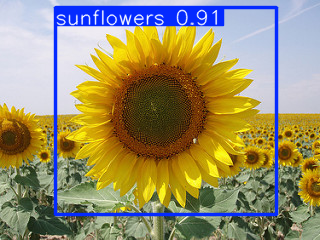

In [16]:
hasil_prediksi = model("/content/1022552002_2b93faf9e7_n.jpg")
hasil_prediksi[0].show()

In [17]:
!find /content -name "*.pt"

/content/runs/detect/train-2/weights/last.pt
/content/runs/detect/train-2/weights/best.pt
/content/runs/detect/train/weights/last.pt
/content/runs/detect/train/weights/best.pt
/content/yolo26n.pt


In [18]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
model.export(format="onnx")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: export success ✅ 1.7s, saved as 'runs/detect/train/weights/best.onnx' (9.3 MB)

Export complete (2.1s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=512 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=512 data=/content/sunflowers-1/data.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.onnx'